In [1]:
# External Imports
import sys
from pathlib import Path
import glob
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torch.nn as nn
from torchinfo import summary
import matplotlib.pyplot as plt

# Internal Imports
sys.path.insert(0, '../src')
from src.DataIntegrity import data_integrity_check
from src.Dataset import split_patients, MriDataset, get_train_transforms, get_val_transforms, get_dataloaders
from src.Model import BaselineModel, fit

In [2]:
data_path = Path("../data/raw/lgg-mri-segmentation/kaggle_3m")
rejected_path = Path("../data/processed/data-integrity")

In [3]:
accepted_data, rejected_data = data_integrity_check(data_path)

[INFO] Data Integrity Checks: 100%|██████████| 112/112 [00:03<00:00, 33.91it/s]

[Info] Data Integrity Pipeline finished
[Info] Segments Accepted = 3929 | Segments Rejected = 0


In [4]:
SPLIT_SEED = 42
train_patients, val_patients, test_patients = split_patients(accepted_data, seed=SPLIT_SEED)

[INFO]  Splitting dataset with seed 42...
[INFO]  Train Set: 76  | Tumor Ratio: 0.352
[INFO]  Valid Set: 17  | Tumor Ratio: 0.360
[INFO]  Test Set:  17  | Tumor Ratio: 0.372


In [5]:
BATCH_SIZE = 2
train_dataloader, val_dataloader, test_dataloader = get_dataloaders(train_patients, val_patients, test_patients, batch_size=BATCH_SIZE)

In [6]:
baseline_model = BaselineModel()
device = "cuda" if torch.cuda.is_available() else "cpu"
baseline_model.to(device)

BaselineModel(
  (layer1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(2, 2), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(2, 2), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Flatten(start_dim=1, end_dim=-1)
  (layer4): Sequential(
    (0): Linear(in_features=96800, out_features=256, bias=True)
    (1): ReLU()
  )
  (layer5): Linear(in_features=256, out_features=2, bias=True)
)

In [7]:
epoch_data = fit(
    model = baseline_model,
    train_data = train_dataloader,
    valid_data = val_dataloader,
    optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3),
    loss_fn = nn.CrossEntropyLoss(),
    device = device,
    epochs=15,
    patience=5
)

Epoch [1/15 <0:00:23><0/5>] Loss [Train | Validation]: 0.6310 | 0.5684 Accuracy: 0.7130 | 0.7189
Epoch [2/15 <0:00:22><0/5>] Loss [Train | Validation]: 0.5024 | 0.5809 Accuracy: 0.7565 | 0.7017
Epoch [3/15 <0:00:22><1/5>] Loss [Train | Validation]: 0.4272 | 0.6352 Accuracy: 0.7953 | 0.7075
Epoch [4/15 <0:00:22><2/5>] Loss [Train | Validation]: 0.4193 | 0.4839 Accuracy: 0.8107 | 0.7629
Epoch [5/15 <0:00:22><0/5>] Loss [Train | Validation]: 0.4012 | 0.6489 Accuracy: 0.8344 | 0.7438
Epoch [6/15 <0:00:22><1/5>] Loss [Train | Validation]: 0.3487 | 0.5749 Accuracy: 0.8455 | 0.7495
Epoch [7/15 <0:00:22><2/5>] Loss [Train | Validation]: 0.3345 | 0.9442 Accuracy: 0.8502 | 0.7285
Epoch [8/15 <0:00:22><3/5>] Loss [Train | Validation]: 0.3377 | 0.5886 Accuracy: 0.8588 | 0.7228
Epoch [9/15 <0:00:23><4/5>] Loss [Train | Validation]: 0.3105 | 0.5718 Accuracy: 0.8635 | 0.6788
[INFO] Patience reached, best epoch was 4 with 0.4839 validation loss.


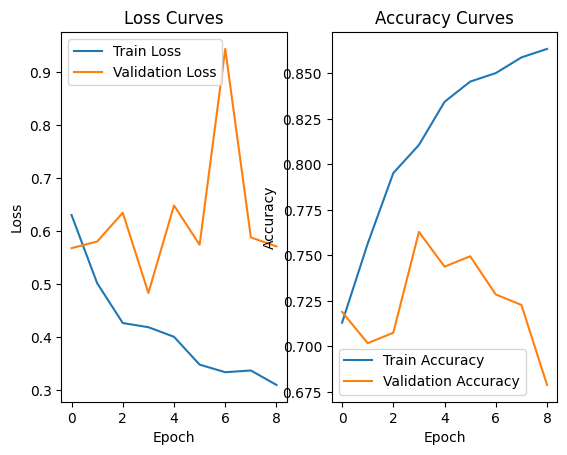

In [8]:
train_loss, val_loss, train_acc, val_acc = zip(*epoch_data.values())

# Display in matplotlib
fig, axs = plt.subplots(1, 2)

axs[0].plot(train_loss, label="Train Loss")
axs[0].plot(val_loss, label="Validation Loss")
axs[0].set_title("Loss Curves")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].plot(train_acc, label="Train Accuracy")
axs[1].plot(val_acc, label="Validation Accuracy")
axs[1].set_title("Accuracy Curves")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
plt.show()